In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/telco_churn_cleaned.csv')
print("Shape:", df.shape)
df.head()

Shape: (7032, 20)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,1,Electronic check,29.85,29.85,0
1,1,0,0,0,34,1,No,DSL,Yes,No,Yes,No,No,No,One year,0,Mailed check,56.95,1889.50,0
2,1,0,0,0,2,1,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,1,Mailed check,53.85,108.15,1
3,1,0,0,0,45,0,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,0,Bank transfer (automatic),42.30,1840.75,0
4,0,0,0,0,2,1,No,Fiber optic,No,No,No,No,No,No,Month-to-month,1,Electronic check,70.70,151.65,1


Overall churn rate: 26.58%


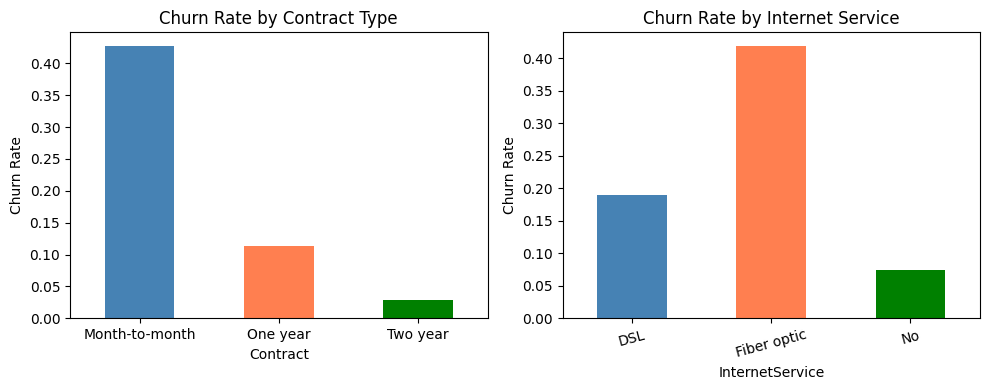

In [2]:
# Churn rate overall
churn_rate = df['Churn'].mean() * 100
print(f"Overall churn rate: {churn_rate:.2f}%")

# Churn by contract type
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
df.groupby('Contract')['Churn'].mean().plot(kind='bar', color=['steelblue', 'coral', 'green'])
plt.title('Churn Rate by Contract Type')
plt.ylabel('Churn Rate')
plt.xticks(rotation=0)

plt.subplot(1, 2, 2)
df.groupby('InternetService')['Churn'].mean().plot(kind='bar', color=['steelblue', 'coral', 'green'])
plt.title('Churn Rate by Internet Service')
plt.ylabel('Churn Rate')
plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

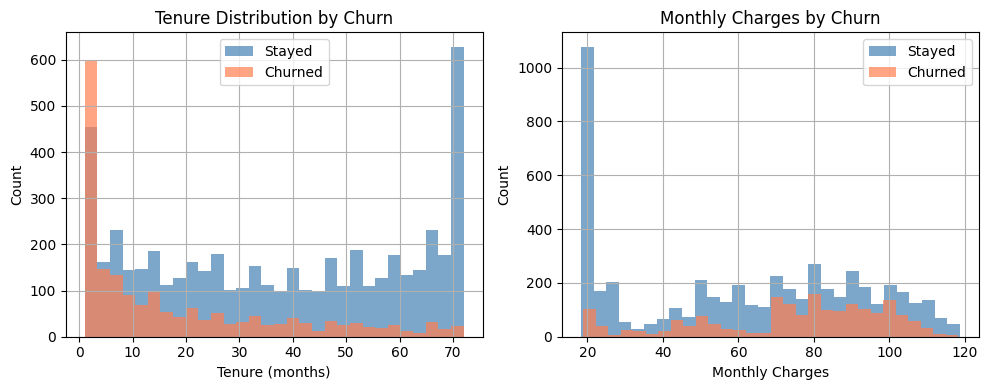

In [3]:
# Tenure vs Churn
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
df[df['Churn']==0]['tenure'].hist(bins=30, alpha=0.7, color='steelblue', label='Stayed')
df[df['Churn']==1]['tenure'].hist(bins=30, alpha=0.7, color='coral', label='Churned')
plt.title('Tenure Distribution by Churn')
plt.xlabel('Tenure (months)')
plt.ylabel('Count')
plt.legend()

plt.subplot(1, 2, 2)
df[df['Churn']==0]['MonthlyCharges'].hist(bins=30, alpha=0.7, color='steelblue', label='Stayed')
df[df['Churn']==1]['MonthlyCharges'].hist(bins=30, alpha=0.7, color='coral', label='Churned')
plt.title('Monthly Charges by Churn')
plt.xlabel('Monthly Charges')
plt.ylabel('Count')
plt.legend()

plt.tight_layout()
plt.show()

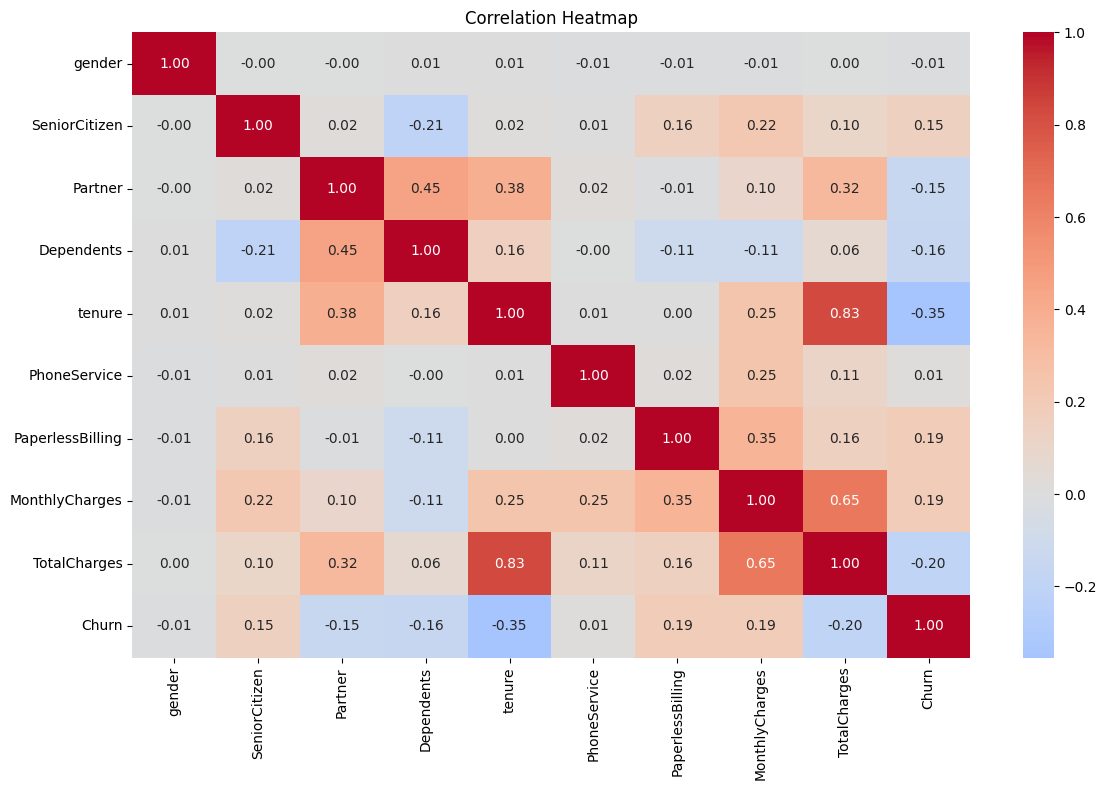

In [4]:
# Correlation heatmap
plt.figure(figsize=(12, 8))
numeric_df = df.select_dtypes(include=['int64', 'float64'])
sns.heatmap(numeric_df.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

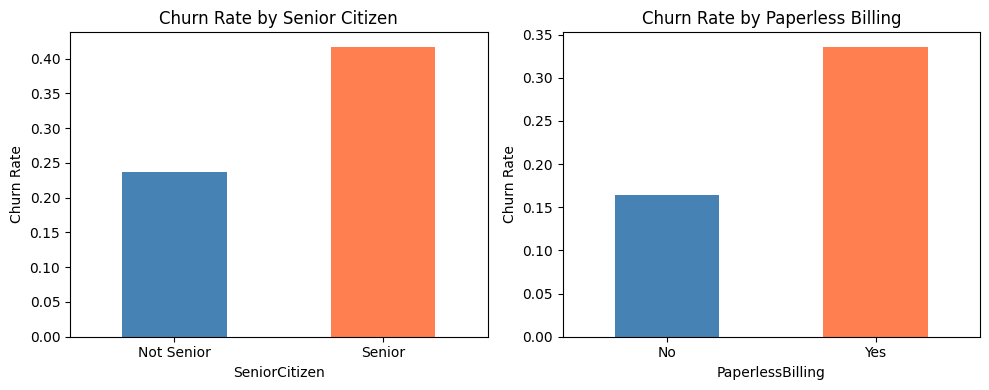

In [5]:
# Senior citizen churn
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
df.groupby('SeniorCitizen')['Churn'].mean().plot(kind='bar', color=['steelblue', 'coral'])
plt.title('Churn Rate by Senior Citizen')
plt.xticks([0, 1], ['Not Senior', 'Senior'], rotation=0)
plt.ylabel('Churn Rate')

plt.subplot(1, 2, 2)
df.groupby('PaperlessBilling')['Churn'].mean().plot(kind='bar', color=['steelblue', 'coral'])
plt.title('Churn Rate by Paperless Billing')
plt.xticks([0, 1], ['No', 'Yes'], rotation=0)
plt.ylabel('Churn Rate')

plt.tight_layout()
plt.show()